In [10]:
import matplotlib.pyplot as plt
import jupyter_black
import warnings

warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
import pandas as pd
import math
import numpy as np
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

jupyter_black.load()
import iris
import iris.quickplot as qplt
import iris.plot as iplt

In [47]:
import iris

cubes = iris.load("./_run_dir/model/atmos_r30_out.nc")

# 1. Extract both wind stress components
taux = cubes.extract_cube("taux")
tauy = cubes.extract_cube("tauy")

# 2. Compute vector magnitude: sqrt(taux^2 + tauy^2)
tau_mag = (taux**2 + tauy**2) ** 0.5

# 3. Set metadata
tau_mag.long_name = "wind stress magnitude"
tau_mag.var_name = "tau_mag"  # Prevents var_name from being None
tau_mag.units = taux.units  # Preserves units from taux/tauy

# 4. Append to list and sort
cubes.sort(key=lambda c: c.var_name or "")
cubes.append(tau_mag)

cubes

[<iris 'Cube' of surface albedo              / (percent) (latitude: 80; longitude: 96)>,
<iris 'Cube' of divergence spectral         / (cm**2/sec) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of divergence spectral tau-1   / (cm**2/sec) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of evaporation                 / (cm/day) (latitude: 80; longitude: 96)>,
<iris 'Cube' of Packed cloud flags          / (unknown) (latitude: 80; longitude: 96)>,
<iris 'Cube' of liq. water flux into ocean  / (cm/sec) (latitude: 80; longitude: 96)>,
<iris 'Cube' of Precipitation               / (cm/day) (latitude: 80; longitude: 96)>,
<iris 'Cube' of sfc pressure spectral       / (dynes/cm**2) (nwave   : 32; mwave   : 62)>,
<iris 'Cube' of sfc pressure spectral tau-1 / (dynes/cm**2) (nwave   : 32; mwave   : 62)>,
<iris 'Cube' of total heat flux into ocean  / (cal/cm**2/s) (latitude: 80; longitude: 96)>,
<iris 'Cube' of mixing ratio spectral       / (unknown) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of mixing ratio spectral tau-1 / (unknown) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of radition ten spectral       / (C/sec) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of runoff                      / (cm/day) (latitude: 80; longitude: 96)>,
<iris 'Cube' of SLWDP (see code for defin)  / (cal/cm**2) (latitude: 80; longitude: 96)>,
<iris 'Cube' of snowfall on ocean           / (cm/sec) (latitude: 80; longitude: 96)>,
<iris 'Cube' of snowfall                    / (cm/day) (latitude: 80; longitude: 96)>,
<iris 'Cube' of snow depth                  / (cm) (latitude: 80; longitude: 96)>,
<iris 'Cube' of snowmelt                    / (cm/day) (latitude: 80; longitude: 96)>,
<iris 'Cube' of frz. water flux into ocean  / (cm/sec) (latitude: 80; longitude: 96)>,
<iris 'Cube' of soil moisture               / (cm) (latitude: 80; longitude: 96)>,
<iris 'Cube' of Sublimation                 / (cm/day) (latitude: 80; longitude: 96)>,
<iris 'Cube' of East-west wind stress       / (dyne/cm**2) (latitude: 80; longitude: 96)>,
<iris 'Cube' of north-sth wind stress       / (dyne/cm**2) (latitude: 80; longitude: 96)>,
<iris 'Cube' of temperature spectral        / (C) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of temperature spectral tau-1  / (C) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of tmean (see code for defin)  / (K) (klevels : 18)>,
<iris 'Cube' of tmnshr(see code for defin)  / (K) (klevelsp: 19)>,
<iris 'Cube' of SST on atm grid             / (K) (latitude: 80; longitude: 96)>,
<iris 'Cube' of skin temperature            / (K) (latitude: 80; longitude: 96)>,
<iris 'Cube' of vorticity spectral          / (cm**2/sec) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of vorticity spectral tau-1    / (cm**2/sec) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of sea ice thickness           / (cm) (latitude: 80; longitude: 96)>,
<iris 'Cube' of Ycemlt (see code for defin) / (cm/sec) (latitude: 80; longitude: 96)>,
<iris 'Cube' of zstar        spectral       / (cm) (nwave   : 32; mwave   : 62)>,
<iris 'Cube' of wind stress magnitude / (dyne/cm**2) (latitude: 80; longitude: 96)>]

In [48]:
pd.DataFrame(
    [{"Long Name": cube.long_name, "Var Name": cube.var_name} for cube in cubes]
)

,Long Name,Var Name
0,surface albedo,calb
1,divergence spectral,div
2,divergence spectral tau-1,divm
3,evaporation,evapor
4,Packed cloud flags,kflags
5,liq. water flux into ocean,per
6,Precipitation,precip
7,sfc pressure spectral,psln
8,sfc pressure spectral tau-1,pslnm
9,total heat flux into ocean,qao


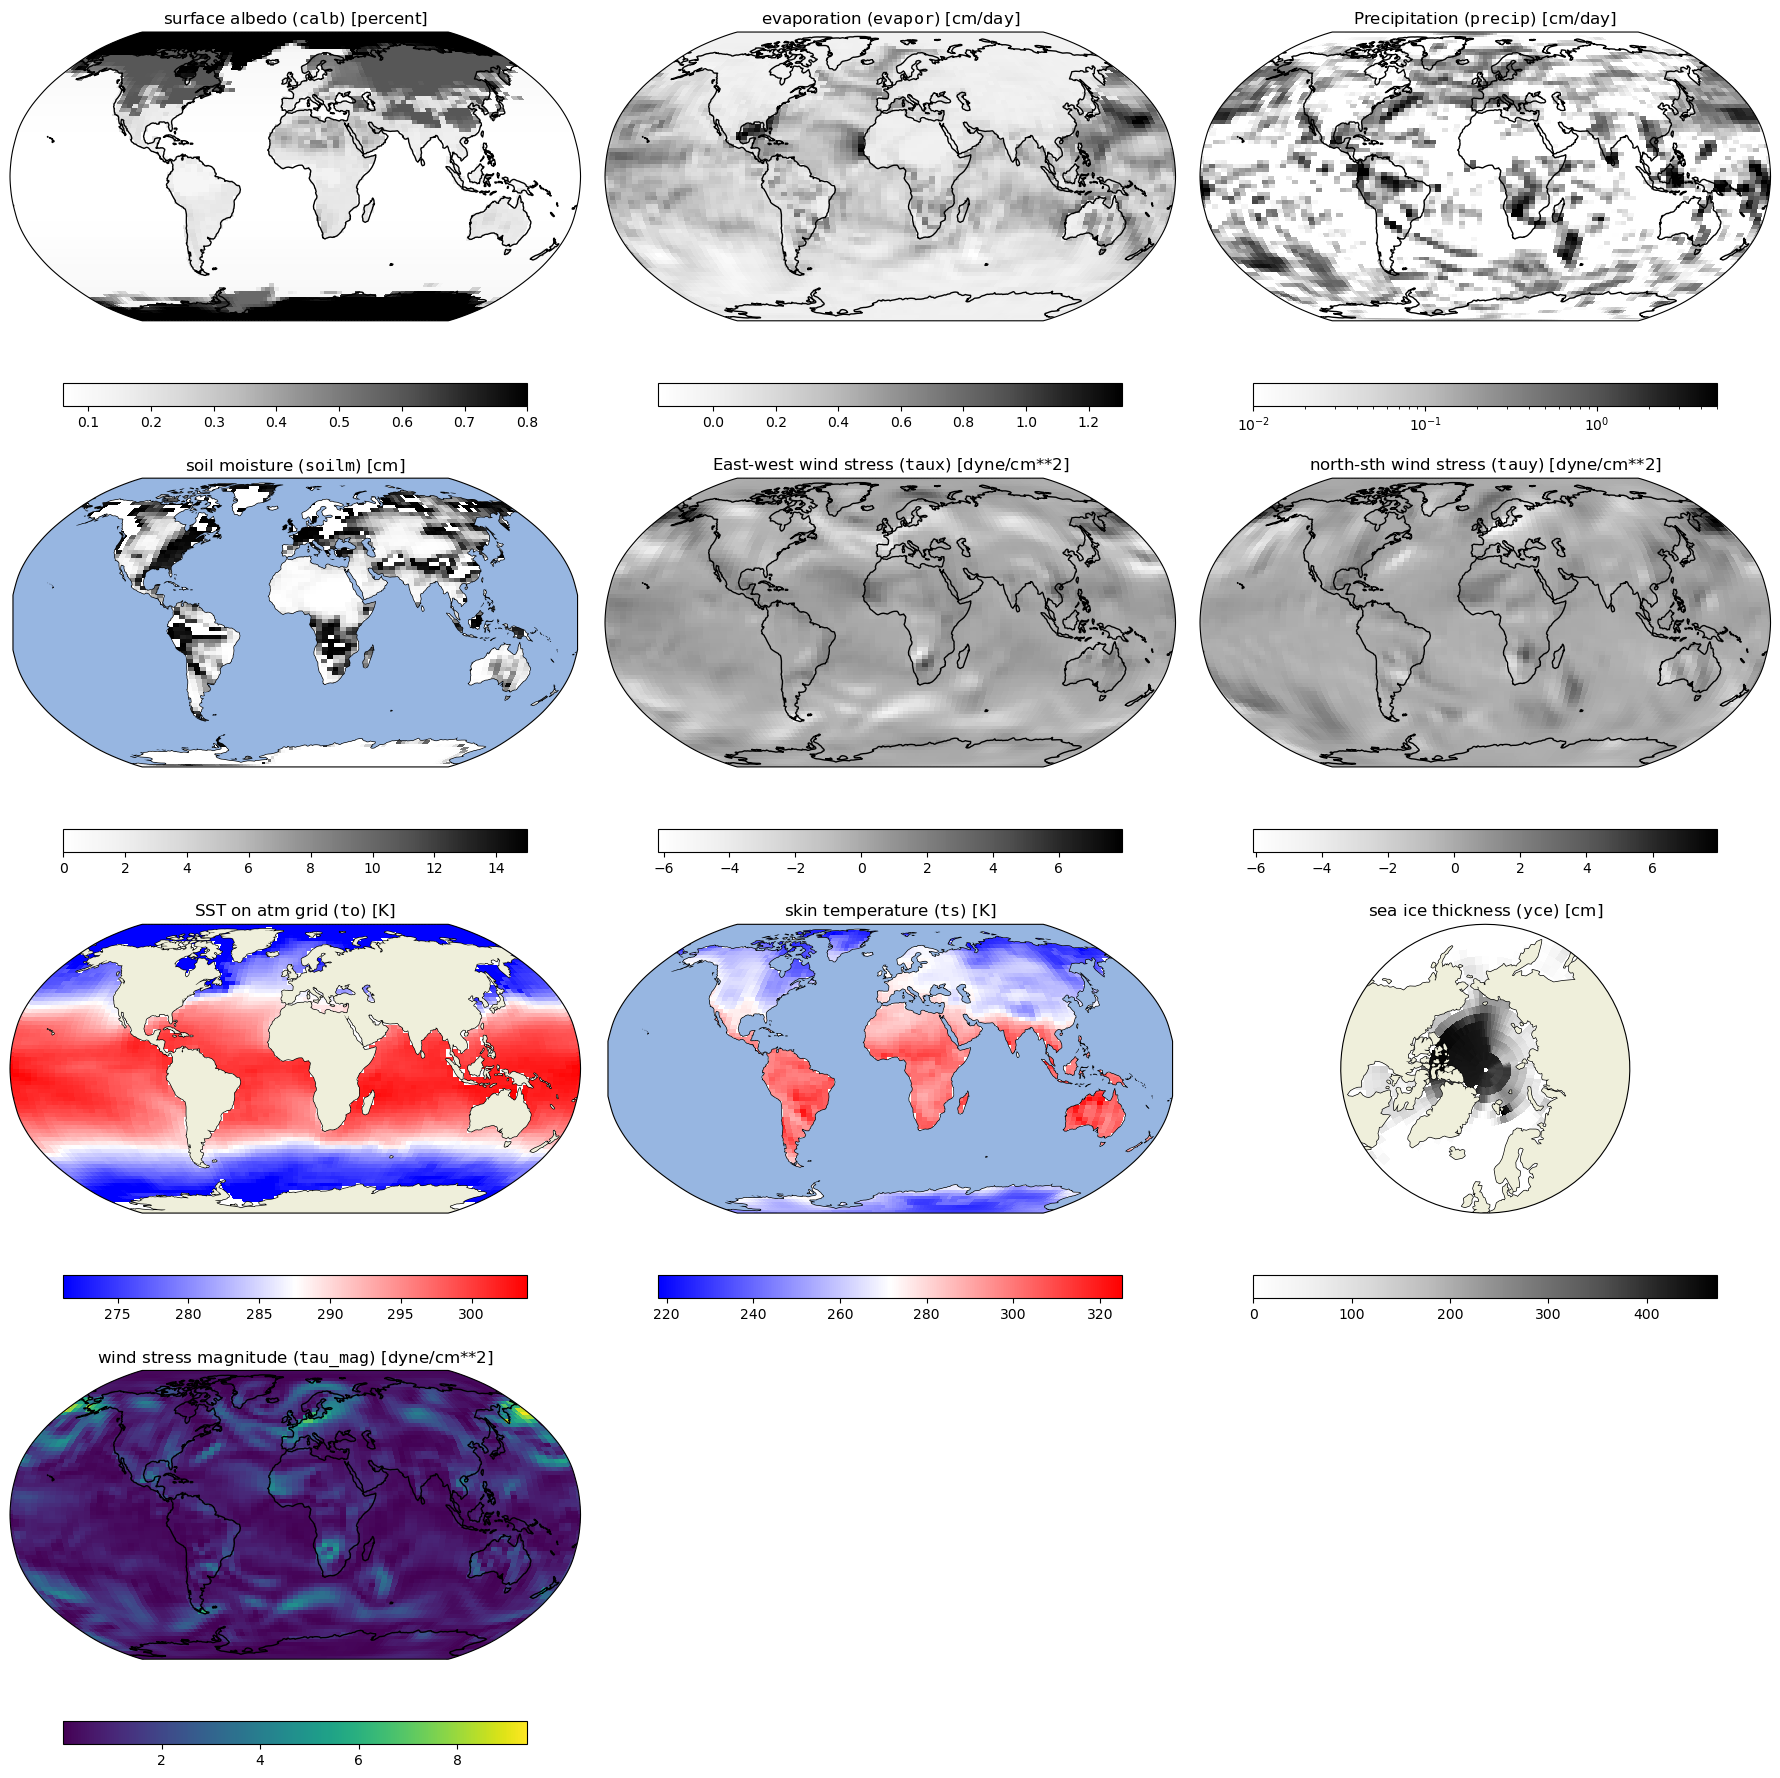

In [51]:
import math
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

indices = [
    i
    for i, cube in enumerate(cubes)
    if cube.coords("latitude")
    and not any(
        word in (cube.long_name or "").lower()
        for word in (
            "melt",
            "mlt",
            "snow",
            "cloud",
            "slwdp",
            "flux",
            "sublimation",
            "runoff",
        )
    )
]

ncols = 3
nrows = math.ceil(len(indices) / ncols)

fig = plt.figure(figsize=(6 * ncols, 4.5 * nrows))

# Pre-compute the circular boundary path for reuse
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle_boundary = mpath.Path(verts * radius + center)

for i, index in enumerate(indices):
    plotthis = cubes[index]
    var = plotthis.var_name or ""
    is_polar = "yce" in var.lower()

    # 1. Pick projection
    proj = ccrs.NorthPolarStereo() if is_polar else ccrs.Robinson()

    ax = fig.add_subplot(nrows, ncols, i + 1, projection=proj)

    # 2. Make polar plots circular & zoom to Arctic
    if is_polar:
        ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
        ax.set_boundary(
            circle_boundary, transform=ax.transAxes
        )  # <--- Truncates square boundary into a circle

    # Data masks
    if var == "to":
        plotthis.data = np.ma.masked_values(plotthis.data, 273.16)
    if var == "ts":
        plotthis.data = np.ma.masked_where(plotthis.data < 0, plotthis.data)
    if var == "soilm":
        plotthis.data = np.ma.masked_where(plotthis.data == 15, plotthis.data)
    if var in ("sublim", "qao"):
        plotthis.data = np.ma.masked_where(plotthis.data == -0.0, plotthis.data)

    lat = plotthis.coord("latitude").points
    lon = plotthis.coord("longitude").points

    cmap = "bwr" if var in ("to", "ts") else "Greys"
    if "wind stress magnitude" in plotthis.long_name.lower():
        cmap = "viridis"

    ax.coastlines()

    long_name_clean = (plotthis.long_name or "").rstrip()
    var_code = var.replace("_", r"\_")
    ax.set_title(f"{long_name_clean} ($\mathtt{{{var_code}}}$) [{plotthis.units}]")

    mesh = ax.pcolormesh(
        lon,
        lat,
        plotthis.data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=(
            LogNorm(vmin=0.01, vmax=5)
            if "precip" in (plotthis.long_name or "").lower()
            else None
        ),
    )

    if any(term in (plotthis.long_name or "").lower() for term in ("sst", "sea ice")):
        ax.add_feature(cfeature.LAND, zorder=2)
    if any(
        term in (plotthis.long_name or "").lower() for term in ("skin temp", "soil")
    ):
        ax.add_feature(cfeature.OCEAN, zorder=2)

    fig.colorbar(mesh, ax=ax, orientation="horizontal", shrink=0.8)

plt.tight_layout()
plt.show()